In [1]:
import pandas as pd
import numpy as np
from scipy.stats import ttest_ind
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(r'C:\Users\win10\OneDrive\Desktop\Data-Projects\Portfolio Project\ab-testing-regression-project\01_Data\cleaned_marketing_campaign.csv')
df.head()

,Date,Platform,Ad_Spend,Impressions,Clicks,CTR,Conversions,Conversion_Rate,Revenue
0,2026-06-08,google,409.31,5332.0,185.0,3.47,9,4.864865,655.63
1,2026-08-26,facebook,758.88,5634.5,899.0,8.66,37,4.115684,3244.35
2,2026-06-11,facebook,503.38,6375.0,321.0,5.04,17,5.295950,1612.57
3,2025-02-01,facebook,447.23,4813.0,146.0,3.03,4,2.739726,180.13
4,2026-09-09,facebook,338.34,2706.0,304.0,11.23,21,6.907895,1240.05


# Business Problem

The marketing agency wants to determine whether Google Ads or Facebook Ads produces better conversion rates.

We will use A/B Testing to identify whether the difference between platforms is statistically significant.

In [2]:
facebook = df[df['Platform'] == 'facebook']
google = df[df['Platform'] == 'google']

In [3]:
fb_conversion = facebook['Conversion_Rate']
gg_conversion = google['Conversion_Rate']

# Hypothesis Testing

## Null Hypothesis (H₀)
There is no significant difference in conversion rates between Facebook and Google Ads.

## Alternative Hypothesis (H₁)
There is a significant difference in conversion rates between Facebook and Google Ads.

In [4]:
# PERFORM T-TEST 

t_stat, p_value = ttest_ind(fb_conversion, gg_conversion)
print("T-Statistics:", t_stat)
print("P-Value:", p_value)

T-Statistics: -22.968529363455158
P-Value: 2.140003212684722e-94


In [5]:
alpha = 0.05
if p_value < alpha:
    print("Reject Null Hypothesis")
    print("Statistically Significant Difference Exists") 
else:
    print("Fail to Reject Null Hypothesis")
    print("No Statistically Significant Difference")

Reject Null Hypothesis
Statistically Significant Difference Exists


# Interpretation

If the p-value is less than 0.05:

- The difference between platforms is statistically significant.
- One platform genuinely performs better.
- The result is unlikely due to random chance.

If the p-value is greater than 0.05:

- The observed difference may be due to randomness.
- We cannot confidently say one platform is superior.

## PLATFORM COMPARISON
Mean Conversion Rates

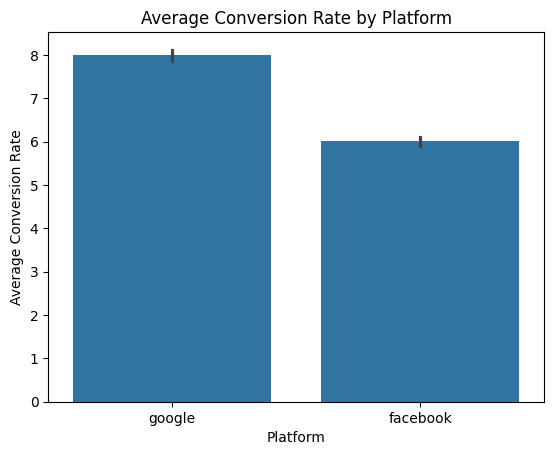

In [6]:
platforms_mean = df.groupby("Platform")["Conversion_Rate"].mean()

sns.barplot(data=df, x="Platform", y="Conversion_Rate")
plt.title("Average Conversion Rate by Platform")
plt.xlabel("Platform")  
plt.ylabel("Average Conversion Rate")
plt.show()

DISTRIBUTION ANALYSIS

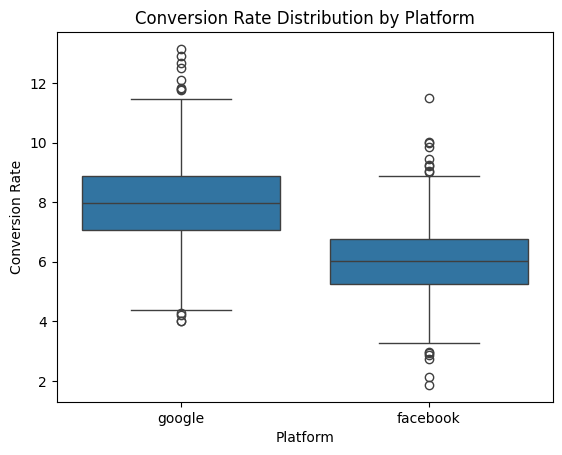

In [7]:
sns.boxplot(data=df, x="Platform", y="Conversion_Rate")
plt.title("Conversion Rate Distribution by Platform")
plt.xlabel("Platform")
plt.ylabel("Conversion Rate")
plt.show()

# Business Recommendation

Based on the A/B testing results:

- Google Ads demonstrated higher average conversion rates.
- Statistical testing confirmed the difference is significant.
- The marketing agency should prioritize budget allocation toward Google Ads campaigns.

However, Facebook Ads may still provide value for brand awareness and broader audience reach.

EXPORTING SUMMARY FOR POWER BI

In [8]:
summary = pd.DataFrame({
    "Platform": ["facebook", "google"],
    "Average_Conversion_Rate": [fb_conversion.mean(), gg_conversion.mean()]
})
summary.to_csv(r'C:\Users\win10\OneDrive\Desktop\Data-Projects\Portfolio Project\ab-testing-regression-project\01_Data\conversion_rate_summary.csv', index=False)

summary.to_csv('ab_testing_summary.csv', index=False)